In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb


from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay, roc_auc_score

from sklearn.preprocessing import LabelEncoder





In [2]:
df_Bank_churn = pd.read_csv("../Data/raw/Bank_Churn.csv")
df_Bank_churn.shape

(10000, 13)

In [3]:
df_Bank_churn.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df_Bank_churn.duplicated().sum()

np.int64(0)

In [5]:
df_Bank_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [6]:
df_Bank_churn.drop(columns=["CustomerId","Exited","IsActiveMember","HasCrCard"]).describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


Text(0.5, 1.0, 'Répartition des clients par genre')

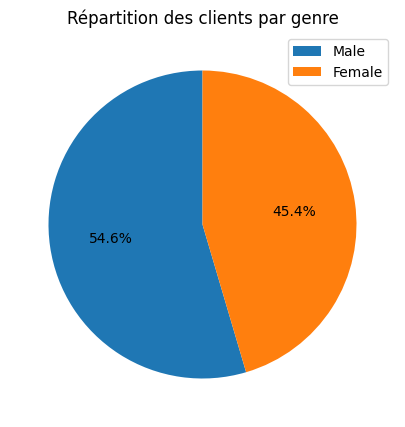

In [7]:
count_Gender = df_Bank_churn["Gender"].value_counts()
unique_Gender = df_Bank_churn["Gender"].unique()

plt.figure(figsize= (6,5))
plt.pie(count_Gender,autopct='%1.1f%%',startangle=90)
plt.legend(count_Gender.index,)
plt.title("Répartition des clients par genre")


In [8]:
df_Bank_churn["Geography"].value_counts(normalize=True)*100

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

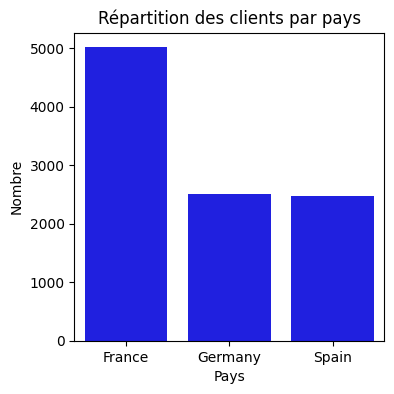

In [9]:
# Barplot pour voir la nationalité la plus représentée

count_Geography = df_Bank_churn["Geography"].value_counts()

plt.figure(figsize= (4,4))
sb.barplot(x=count_Geography.index,y=count_Geography.values, color= "blue")
plt.title("Répartition des clients par pays")
plt.xlabel("Pays")
plt.ylabel("Nombre")
plt.show()


In [10]:
# la moyenne de creditscore par pays
df_Bank_churn.groupby("Geography")["CreditScore"].mean()

Geography
France     649.668329
Germany    651.453567
Spain      651.333872
Name: CreditScore, dtype: float64

In [11]:
# la moyenne de Creditscore entre client désabonné et fidéle 
df_Bank_churn.groupby("Exited")["CreditScore"].mean()

Exited
0    651.853196
1    645.351497
Name: CreditScore, dtype: float64

Text(0.5, 1.0, 'Distribution - solde de compte')

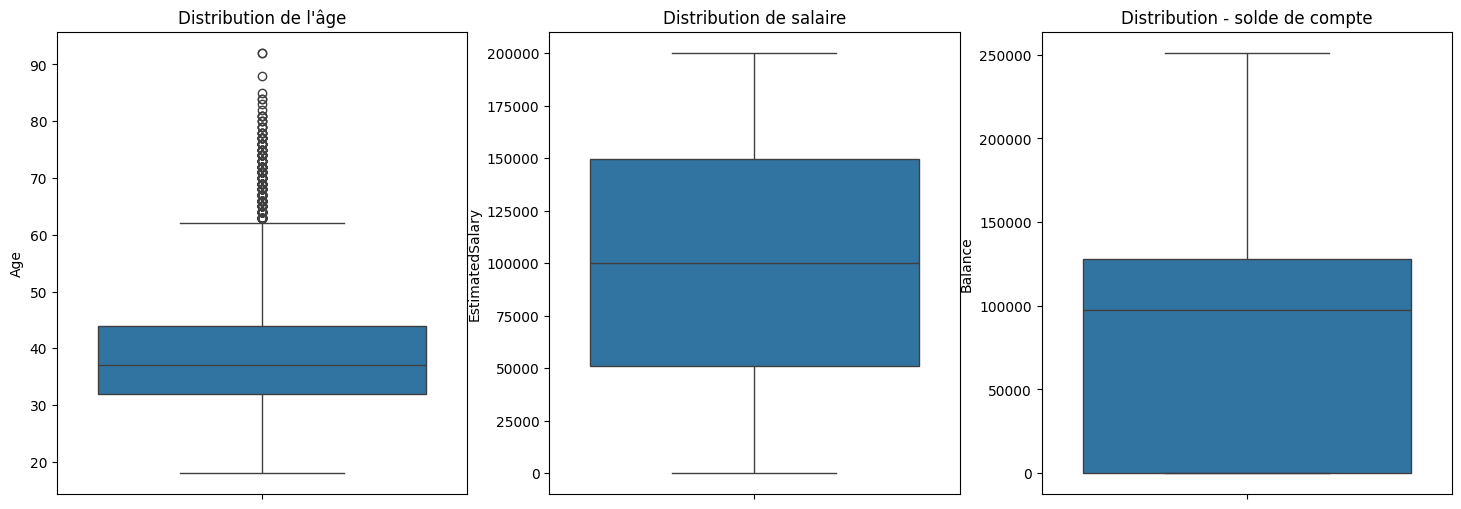

In [12]:
# Boxplot distribution d'Age , salaire , Balance("solde compte")

plt.figure(figsize=(18,6))

# Age
plt.subplot(1,3,1)
sb.boxplot(y=df_Bank_churn["Age"])
plt.title("Distribution de l'âge")

# salaire
plt.subplot(1,3,2)
sb.boxplot(y=df_Bank_churn["EstimatedSalary"])
plt.title("Distribution de salaire")


# Balance("solde compte")
plt.subplot(1, 3, 3)  # 3e graphique
sb.boxplot(y=df_Bank_churn['Balance'])
plt.title('Distribution - solde de compte')

*****************    Analyse de la variable Age "Outliers" ************

In [13]:
# calcule de la Borne supérieure IQR pour les outliers
Q1 = 32  
Q3 = 44 
IQR = Q3 - Q1 ,   
IQR = 32 - 44  ,
IQR = 12
Q3 + 1.5 * IQR
Up = 44 + 1.5 * 12
Up


62.0

In [14]:
# Nb de clients qui ont un Age superieur a 62 ans
df_Bank_churn[df_Bank_churn["Age"] > 62].shape[0]

359

In [15]:
# calcule de Taux de churn des client plus agé de plus de 62 ans 
df_Bank_churn[df_Bank_churn["Age"] > 62]["Exited"].mean()*100

np.float64(20.334261838440113)

In [16]:
# Calcule du Taux de chrurn General du dataset 
df_Bank_churn["Exited"].mean()*100

np.float64(20.369999999999997)

Bien que l’IQR ait identifié les clients de plus de 62 ans comme outliers statistiques, leur taux de churn (20,33 %) est quasiment identique au taux global (20,36 %). Ces observations ne présentent donc pas de comportement particulier et ont été conservées dans l’analyse.

                           **************  Resumé Churn > 62 ans ************

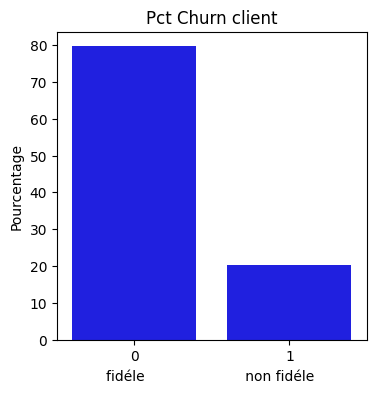

In [17]:
clients_churn = df_Bank_churn["Exited"].value_counts(normalize=True)*100

plt.figure(figsize= (4,4))
sb.barplot(x=clients_churn.index,y=clients_churn.values, color= "blue")
plt.title("Pct Churn client")
plt.xlabel("fidéle                       non fidéle ")
plt.ylabel("Pourcentage")
plt.show()

In [18]:
bins = [0, 30, 50, 60, 100]
labels = ["<30", "30-49", "50-59", "60+"]


df_Bank_churn["Category_Age"] = pd.cut(df_Bank_churn["Age"],bins=bins , labels=labels , right=False)


In [19]:
#import pickle as pkl
#df_bank_csv = df_Bank_churn.to_csv("df_bank_clean.csv")

In [20]:
# Encoder la colonne Gender en 0= femme et 1 = homme
le = LabelEncoder()
df_Bank_churn["Gender"]= le.fit_transform(df_Bank_churn["Gender"])

In [21]:
# Encoder la colonne Geography 0 et 1
df_Bank_churn = pd.get_dummies(df_Bank_churn, columns=['Geography'])


In [22]:
df_Bank_churn['Geography'] = df_Bank_churn[['Geography_France', 'Geography_Germany', 'Geography_Spain']].idxmax(axis=1)
df_Bank_churn['Geography'] = df_Bank_churn['Geography'].str.replace('Geography_', '')


In [23]:
# remplacer le resultat en booleen par chiffre ebtier dans la colonne Geography_
dummy_cols = [col for col in df_Bank_churn.columns if 'Geography_' in col]
df_Bank_churn[dummy_cols] = df_Bank_churn[dummy_cols].astype(int)

In [24]:
df_Bank_churn.head()

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Category_Age,Geography_France,Geography_Germany,Geography_Spain,Geography
0,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,30-49,1,0,0,France
1,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,30-49,0,0,1,Spain
2,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,30-49,1,0,0,France
3,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,30-49,1,0,0,France
4,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,30-49,0,0,1,Spain


In [25]:
df_Bank_churn.groupby("Geography")["Exited"].mean() * 100


Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [26]:
df_Bank_churn

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Category_Age,Geography_France,Geography_Germany,Geography_Spain,Geography
0,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,30-49,1,0,0,France
1,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,30-49,0,0,1,Spain
2,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,30-49,1,0,0,France
3,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,30-49,1,0,0,France
4,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,30-49,0,0,1,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,1,39,5,0.00,2,1,0,96270.64,0,30-49,1,0,0,France
9996,15569892,Johnstone,516,1,35,10,57369.61,1,1,1,101699.77,0,30-49,1,0,0,France
9997,15584532,Liu,709,0,36,7,0.00,1,0,1,42085.58,1,30-49,1,0,0,France
9998,15682355,Sabbatini,772,1,42,3,75075.31,2,1,0,92888.52,1,30-49,0,1,0,Germany


In [27]:
# Analyse du churn par genre
Taux_de_churn = df_Bank_churn.groupby("Gender")["Exited"].mean()*100
Taux_de_churn


Gender
0    25.071539
1    16.455928
Name: Exited, dtype: float64

***  Analyse du churn par genre ***

On observe que 25 % des clientes (femmes) quittent la banque, contre 16 % des clients (hommes).

→ Cela indique un taux d’attrition significativement plus élevé chez les femmes par rapport aux hommes.
→ L’écart de 9 points de pourcentage suggère une différence comportementale notable entre les deux groupes.

Interprétation:
Le genre semble être une variable explicative du churn.

(0.0, 35.07)

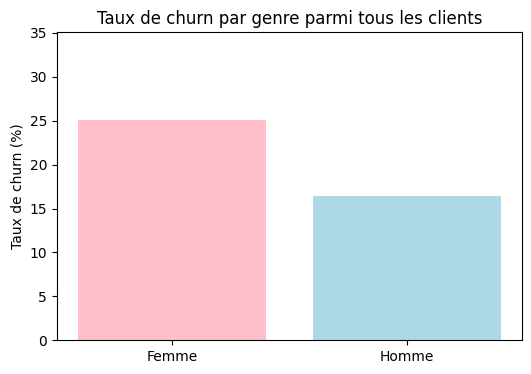

In [28]:
# Taux de churn parmi toutes les femmes et tous les hommes
genres = ["Femme", "Homme"]
taux_churn = [25.07, 16.45]  # en pourcentage

plt.figure(figsize=(6,4))
plt.bar(genres, taux_churn, color=["pink", "lightblue"])
plt.ylabel("Taux de churn (%)")
plt.title("Taux de churn par genre parmi tous les clients")
plt.ylim(0, max(taux_churn)+10)  # un peu d'espace au-dessus des barres

In [29]:
# creation de DataFrame numerique
df_num = df_Bank_churn.drop(columns= ["CustomerId","Surname","IsActiveMember","Category_Age","Geography"])

In [30]:
# Corrélation des variable numerique
df_corr = df_num.corr()

Text(0.5, 1.0, "Matrice de corrélation churn client 'Exited")

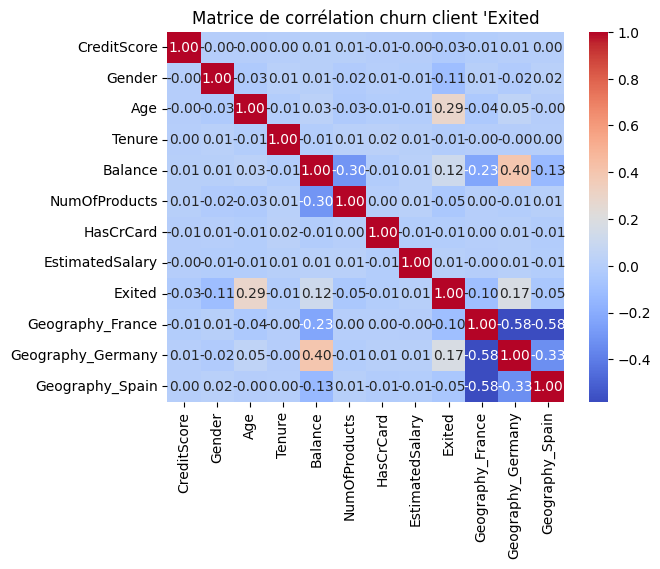

In [31]:
plt.Figure(figsize= (8 , 6))
sb.heatmap(data=df_corr, annot=True, fmt= ".2f",cmap= "coolwarm")
plt.title("Matrice de corrélation churn client 'Exited")

**********Interprétation de la heatmap de corrélation******

Corrélation avec la viriable cible Exited : 

- Age : corrélation = 0,29
Corrélation positive faible à modérée. Cela signifie que plus le client est âgé, plus il a tendance à quitter la banque. Ce n’est pas très fort mais c’est significatif.

- Balance : corrélation = 0,12
→ Très faible corrélation positive. Autrement dit, le solde du compte n’influence que très peu le fait qu’un client quitte la banque.

- Geography_Germany :corrélation positive  0.17  → les clients allemands sont légèrement plus susceptibles de quitter.

- Geography_France :corrélation négative faible  -0.10  → les clients français ont tendance à rester.


Corrélation entre Geography_Germany et Balance : 0,40
→ Il existe une corrélation positive modérée entre le fait qu’un client soit basé en Allemagne et son solde bancaire. Cela suggère que les clients allemands présentent en moyenne un solde plus élevé.

Corrélation entre Geography_France et Balance : -0,23
→ Il existe une corrélation négative faible à modérée entre la variable Geography_France et le solde (Balance). Cela suggère que les clients situés en France ont tendance à avoir un solde inférieur à la moyenne.

***Quels sont les attributs les plus fréquents chez les clients qui se désabonnent que chez ceux qui restent fidèles ? ***

1 - Analyse clients désabonnés:
les attributs les plus fréquents chez les clients qui se désabonnent ??

In [32]:
# les clients désabonné
Client_désabonné = df_Bank_churn[df_Bank_churn["Exited"] == 1]
Client_désabonné

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Category_Age,Geography_France,Geography_Germany,Geography_Spain,Geography
0,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,30-49,1,0,0,France
2,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,30-49,1,0,0,France
5,15574012,Chu,645,1,44,8,113755.78,2,1,0,149756.71,1,30-49,0,0,1,Spain
7,15656148,Obinna,376,0,29,4,115046.74,4,1,0,119346.88,1,<30,0,1,0,Germany
16,15737452,Romeo,653,1,58,1,132602.88,1,1,0,5097.67,1,50-59,0,1,0,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,15672754,Burbidge,498,1,42,3,152039.70,1,1,1,53445.17,1,30-49,0,1,0,Germany
9982,15768163,Griffin,655,0,46,7,137145.12,1,1,0,115146.40,1,30-49,0,1,0,Germany
9991,15769959,Ajuluchukwu,597,0,53,4,88381.21,1,1,0,69384.71,1,50-59,1,0,0,France
9997,15584532,Liu,709,0,36,7,0.00,1,0,1,42085.58,1,30-49,1,0,0,France


Text(0.5, 1.0, 'Distribution - Balance - solde de compte')

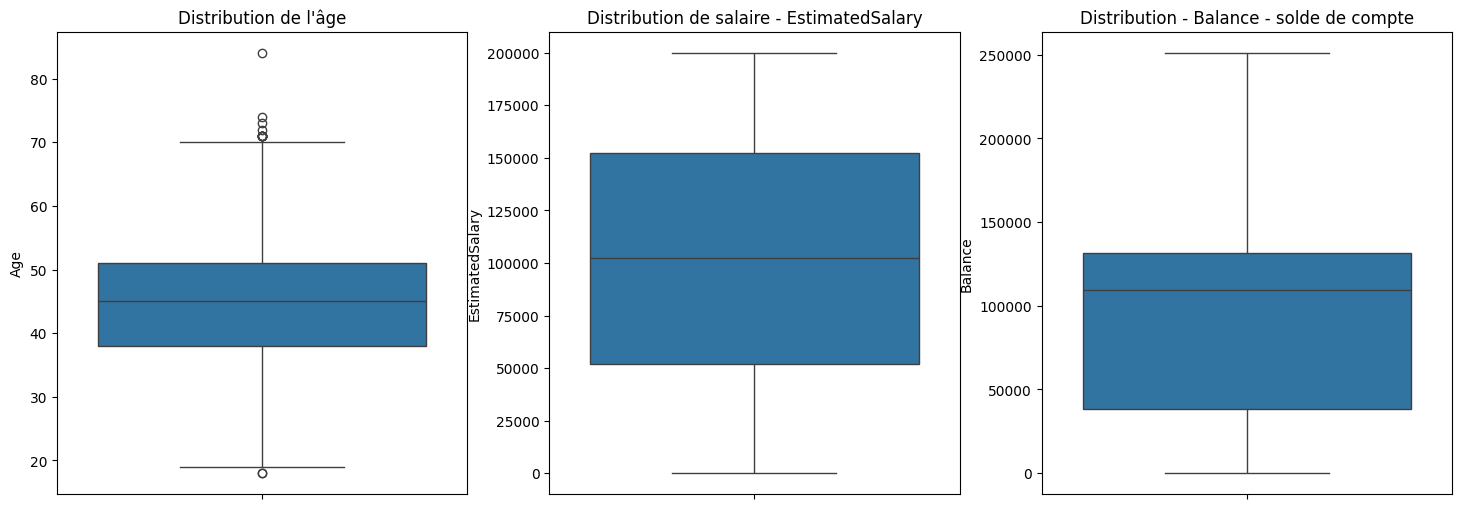

In [33]:
# Boxplot distribution d'Age , salaire , Balance("solde compte") churn == 1 Client désabonnés
plt.figure(figsize=(18,6))

# Age
plt.subplot(1,3,1)
sb.boxplot(y=Client_désabonné["Age"])
plt.title("Distribution de l'âge")

# salaire
plt.subplot(1,3,2)
sb.boxplot(y=Client_désabonné["EstimatedSalary"])
plt.title("Distribution de salaire - EstimatedSalary")


# Balance("solde compte")
plt.subplot(1, 3, 3)  # 3e graphique
sb.boxplot(y=Client_désabonné['Balance'])
plt.title('Distribution - Balance - solde de compte')

***"Taux de désabonnement par pays : comparaison entre clients espagnols, allemands et français"***

In [34]:
# proportion des churners qui sont Français est de 39.76 %
(
    Client_désabonné[
        (Client_désabonné["Geography_France"] == 1) & 
        (Client_désabonné["Exited"] == 1)
    ].shape[0]
    /
    Client_désabonné.shape[0]
) * 100


39.76435935198822

In [35]:
# proportion des churners qui sont Allemands est de 39.96 %
(
    Client_désabonné[
        (Client_désabonné["Geography_Germany"] == 1) & 
        (Client_désabonné["Exited"] == 1)
    ].shape[0]
    /
    Client_désabonné.shape[0]
) * 100

39.9607265586647

In [36]:
# proportion des churners qui sont Espagnoles :  est de 20.27 %
(
    Client_désabonné[
        (Client_désabonné["Geography_Spain"] == 1) & 
        (Client_désabonné["Exited"] == 1)
    ].shape[0]
    /
    Client_désabonné.shape[0]
) * 100

20.274914089347078

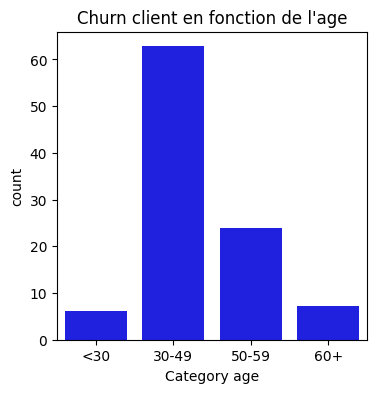

In [37]:
Category_Age = Client_désabonné["Category_Age"].value_counts(normalize=True) * 100

plt.figure(figsize= (4,4))
sb.barplot(x=Category_Age.index,y=Category_Age.values, color= "blue")
plt.title("Churn client en fonction de l'age")
plt.xlabel("Category age")
plt.ylabel("count")
plt.show()



In [38]:
Client_désabonné["EstimatedSalary"].mean()

np.float64(101465.67753068237)

In [39]:
# actif ou non actif    "1302 non actif"
Client_désabonné["IsActiveMember"].value_counts(normalize=True)*100

IsActiveMember
0    63.917526
1    36.082474
Name: proportion, dtype: float64

In [40]:
# Client_désabonné = qui avaient une carte ou non  1424== oui  613== non
Client_désabonné["HasCrCard"].value_counts(normalize=True)*100

HasCrCard
1    69.906726
0    30.093274
Name: proportion, dtype: float64

In [41]:
# Désabonnement Femme VS homme , 55.91 % femmes et 44.08 % hommes
Client_désabonné["Gender"].value_counts(normalize=True)*100

Gender
0    55.915562
1    44.084438
Name: proportion, dtype: float64

In [42]:
Client_désabonné["NumOfProducts"].value_counts(normalize=True)*100

NumOfProducts
1    69.170349
2    17.083947
3    10.800196
4     2.945508
Name: proportion, dtype: float64

2 - Analyse Client fidéles:
les attributs les plus fréquents chez les clients fidéles ??

In [43]:
# les clients fideles
Clients_abonné = df_Bank_churn[df_Bank_churn["Exited"] == 0]
Clients_abonné.head()

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Category_Age,Geography_France,Geography_Germany,Geography_Spain,Geography
1,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,30-49,0,0,1,Spain
3,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,30-49,1,0,0,France
4,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,30-49,0,0,1,Spain
6,15592531,Bartlett,822,1,50,7,0.00,2,1,1,10062.80,0,50-59,1,0,0,France
8,15792365,He,501,1,44,4,142051.07,2,0,1,74940.50,0,30-49,1,0,0,France


Text(0.5, 1.0, 'Distribution - Balance - solde de compte')

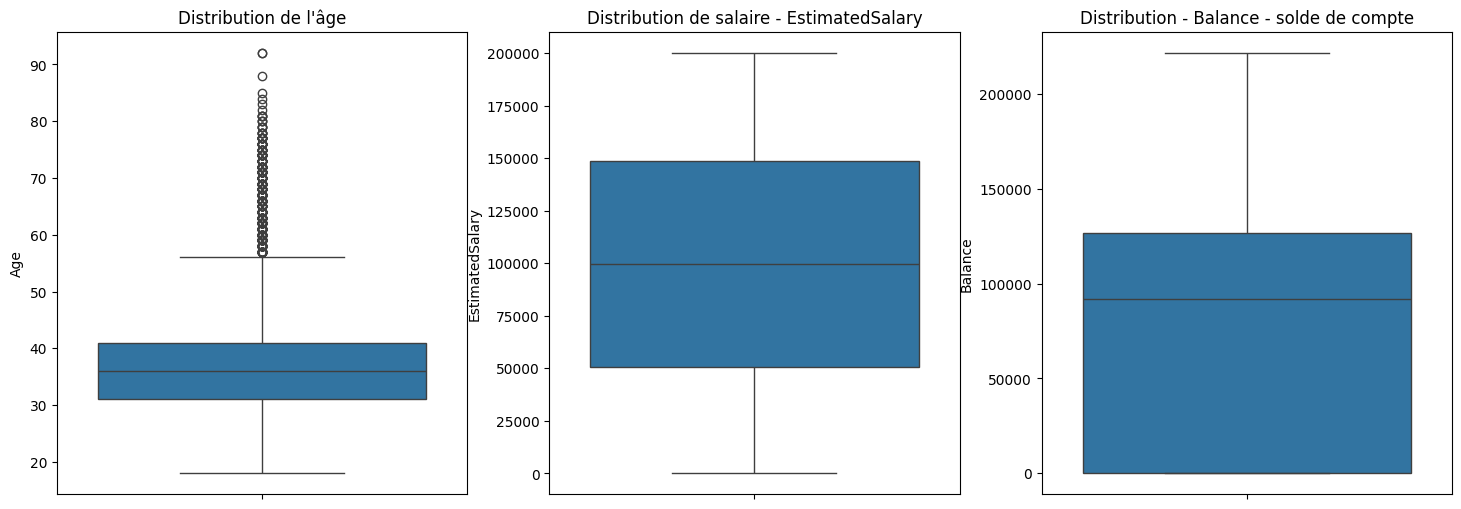

In [44]:
# Boxplot distribution d'Age , salaire , Balance("solde compte") churn == 0 Client fidéles

plt.figure(figsize=(18,6))

# Age
plt.subplot(1,3,1)
sb.boxplot(y=Clients_abonné["Age"])
plt.title("Distribution de l'âge")

# salaire
plt.subplot(1,3,2)
sb.boxplot(y=Clients_abonné["EstimatedSalary"])
plt.title("Distribution de salaire - EstimatedSalary")


# Balance("solde compte")
plt.subplot(1, 3, 3)  # 3e graphique
sb.boxplot(y=Clients_abonné['Balance'])
plt.title('Distribution - Balance - solde de compte')

In [45]:
Clients_abonné.head()

,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Category_Age,Geography_France,Geography_Germany,Geography_Spain,Geography
1,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,30-49,0,0,1,Spain
3,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,30-49,1,0,0,France
4,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,30-49,0,0,1,Spain
6,15592531,Bartlett,822,1,50,7,0.00,2,1,1,10062.80,0,50-59,1,0,0,France
8,15792365,He,501,1,44,4,142051.07,2,0,1,74940.50,0,30-49,1,0,0,France


In [46]:
# moyenne de salaire de cleints qui sont fidéles 
Clients_abonné["EstimatedSalary"].mean()

np.float64(99738.39177194524)

In [47]:
Clients_abonné["Category_Age"].value_counts()

Category_Age
30-49    5685
<30      1517
50-59     382
60+       379
Name: count, dtype: int64

In [48]:
# Clients_abonné - actif ou non actif    4416 actif ,  "3547 non actif"
Clients_abonné["IsActiveMember"].value_counts(normalize=True)*100

IsActiveMember
1    55.456486
0    44.543514
Name: proportion, dtype: float64

In [49]:
# Client_désabonné = qui avaient une carte ou non  1424== oui  613== non
Clients_abonné["HasCrCard"].value_counts(normalize=True)*100

HasCrCard
1    70.714555
0    29.285445
Name: proportion, dtype: float64

In [50]:
Clients_abonné["NumOfProducts"].value_counts(normalize=True)*100

NumOfProducts
2    53.271380
1    46.150948
3     0.577672
Name: proportion, dtype: float64

********************* Machine learning ***********************

In [51]:
df_ML = df_Bank_churn.drop(columns = ["CustomerId","Surname","Category_Age","Geography"])

In [52]:
# df_ML.to_csv("ML_data.csv",index=False)

In [53]:
df_ML

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [54]:
X = df_ML.drop(columns=["Exited"]) # variable explicatives
Y = df_ML["Exited"] # Cible

In [55]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y ,test_size= 0.2,random_state= 42)

RFC = RandomForestClassifier( 
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42
) 

RFC.fit(X_train,Y_train)
y_proba = RFC.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.3).astype(int)

accuracy = accuracy_score(Y_test, y_pred)
print(accuracy)

confusion_m = confusion_matrix(Y_test,y_pred)
print(confusion_m)

classif_report = classification_report(Y_test, y_pred)
classif_report

0.682
[[1019  588]
 [  48  345]]


'              precision    recall  f1-score   support\n\n           0       0.96      0.63      0.76      1607\n           1       0.37      0.88      0.52       393\n\n    accuracy                           0.68      2000\n   macro avg       0.66      0.76      0.64      2000\nweighted avg       0.84      0.68      0.71      2000\n'

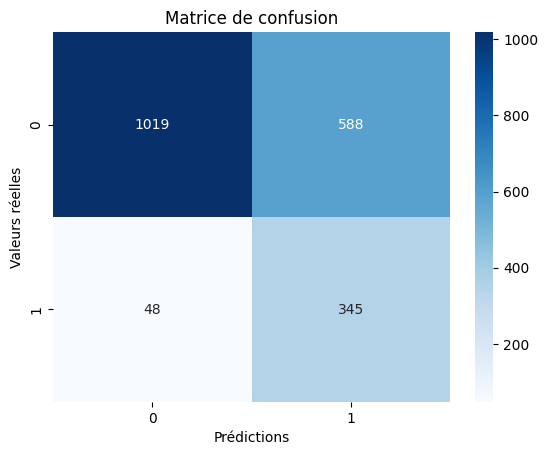

In [56]:
# Matrice de confusion pour RandomForestClassifier 
cm = confusion_m
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

******************************** ML _ XGBClassifier ******************************************

In [57]:


X1_train, X1_test, Y1_train, Y1_test = train_test_split(X, Y ,test_size= 0.2,random_state= 42,stratify=Y)


scale_pos_weight = len(Y1_train[Y1_train==0]) / len(Y1_train[Y1_train==1])

# Création du modèle XGBoost
XGB = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Entraînement
XGB.fit(X1_train, Y1_train)

# Prédictions avec seuil par défaut (0.5)
y1_pred = XGB.predict(X1_test)


accuracy1 = accuracy_score(Y1_test, y1_pred)
print(accuracy1)

confusion_m1 = confusion_matrix(Y1_test,y1_pred)
print(confusion_m1)

classif_report1 = classification_report(Y1_test, y1_pred)
classif_report1

0.826
[[1391  202]
 [ 146  261]]


'              precision    recall  f1-score   support\n\n           0       0.91      0.87      0.89      1593\n           1       0.56      0.64      0.60       407\n\n    accuracy                           0.83      2000\n   macro avg       0.73      0.76      0.74      2000\nweighted avg       0.84      0.83      0.83      2000\n'

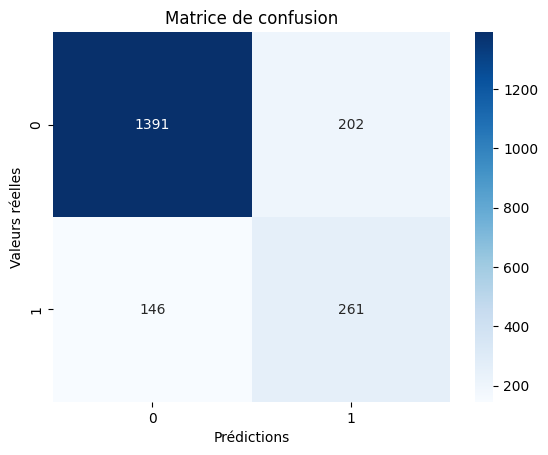

In [58]:
# Matrice de confusion pour XGBOOST 
cm1 = confusion_m1
sb.heatmap(cm1, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.show()

************************* ML_LogisticRegression *****************************************

In [59]:
# Separation des données en entrenement et test
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # Split avec stratification (important en dataset déséquilibré)
)

# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X3_train)
X_test_scaled = scaler.transform(X3_test)

# Modèle
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # ajuste automatiquement le déséquilibre
    solver='liblinear'
)

# Entraînement correct
model.fit(X_train_scaled, y3_train)

# Probabilités
y_proba = model.predict_proba(X_test_scaled)[:, 1] 

# Ajustement du seuil (tu peux tester 0.4 / 0.45 / 0.5 / 0.55)
threshold = 0.55
y_pred = (y_proba > threshold).astype(int)

# Évaluation
print("Classification Report")
print(classification_report(y3_test, y_pred))




Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1593
           1       0.42      0.64      0.51       407

    accuracy                           0.75      2000
   macro avg       0.66      0.71      0.67      2000
weighted avg       0.80      0.75      0.77      2000



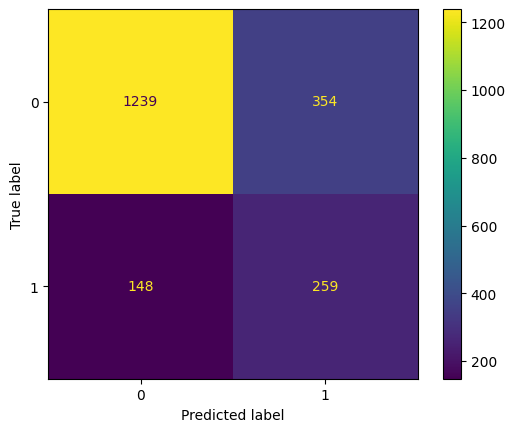

In [60]:
# Matrice de confusion
cm3 = confusion_matrix(y3_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=[0, 1])
disp.plot()
plt.show()